In [34]:
import argparse
import os

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

#configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [8]:
df_path = '/content/drive/MyDrive/Hack-Earth Hackathon/HackEarth_Fire/uttarakhand_fire_data.csv'

In [9]:
df = pd.read_csv(df_path)

In [10]:
df.head(20)

,EVI,LST_Day_1km,LST_Night_1km,NDVI,aspect,burn_count_5yr,burned_last_5yr,elevation,fire_occurred,land_cover,lst_day_max,ndvi_30day_mean,population,precip_30day,precip_7day,slope,soil_moisture,temperature_2m_max,wind_speed,years_since_last_burn,longitude,latitude
0,0.2487,298.994286,290.235,0.5802,322.753693,0,0,201,0,5,299.90,0.60405,0.807059,0.966622,0.053142,0.054615,0,304.843506,2.550250,5,79.959043,28.737106
1,0.2931,298.405714,291.345,0.5921,303.311829,0,0,207,0,5,299.68,0.65525,0.657179,0.976740,0.024443,0.079163,0,304.603271,2.163758,5,79.959043,28.808971
2,0.3251,298.840000,290.075,0.5944,300.287231,0,0,203,0,5,300.28,0.61790,2.505430,1.208379,0.047092,0.114940,0,304.482178,2.346353,5,79.923111,28.826937
3,0.2494,298.494286,290.875,0.5999,264.440216,0,0,209,0,5,299.60,0.64275,0.781334,0.976740,0.024443,0.149580,0,304.603271,2.163758,5,79.977010,28.826937
4,0.2855,298.425714,291.055,0.6353,261.692749,0,0,216,0,5,299.58,0.68585,0.895809,0.976740,0.024443,0.100304,0,304.603271,2.163758,5,79.994976,28.826937
5,0.3258,298.151429,290.835,0.6551,88.207878,0,0,204,0,2,299.10,0.66760,2.094547,0.976740,0.024443,0.463390,0,304.603271,2.163758,5,80.030909,28.826937
6,0.3579,298.860000,286.896,0.6979,218.825607,1,1,252,0,5,300.86,0.66415,0.821032,0.477626,0.171487,0.502242,0,304.070206,1.235609,2,79.977010,29.024567
7,0.3218,299.432000,290.745,0.6163,180.000000,0,0,250,0,2,302.64,0.63720,1.416239,1.435651,0.865852,0.333313,0,303.999756,2.095854,5,79.599717,29.042533
8,0.3657,298.106667,289.348,0.7020,186.865356,0,0,257,0,2,300.02,0.66830,1.197366,0.551938,0.430738,0.831954,0,304.091690,1.471548,5,79.905145,29.042533
9,0.3376,299.623333,287.588,0.6844,210.212128,0,0,264,0,5,301.98,0.67040,0.807375,0.477626,0.171487,0.922267,0,304.070206,1.235609,5,79.977010,29.042533


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29122 entries, 0 to 29121
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EVI                    29122 non-null  float64
 1   LST_Day_1km            29122 non-null  float64
 2   LST_Night_1km          29122 non-null  float64
 3   NDVI                   29122 non-null  float64
 4   aspect                 29122 non-null  float64
 5   burn_count_5yr         29122 non-null  int64  
 6   burned_last_5yr        29122 non-null  int64  
 7   elevation              29122 non-null  int64  
 8   fire_occurred          29122 non-null  int64  
 9   land_cover             29122 non-null  int64  
 10  lst_day_max            29122 non-null  float64
 11  ndvi_30day_mean        29122 non-null  float64
 12  population             29122 non-null  float64
 13  precip_30day           29122 non-null  float64
 14  precip_7day            29122 non-null  float64
 15  sl

In [12]:
df.describe()

,EVI,LST_Day_1km,LST_Night_1km,NDVI,aspect,burn_count_5yr,burned_last_5yr,elevation,fire_occurred,land_cover,lst_day_max,ndvi_30day_mean,population,precip_30day,precip_7day,slope,soil_moisture,temperature_2m_max,wind_speed,years_since_last_burn,longitude,latitude
count,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000,29122.0,29122.000000,29122.000000,29122.000000,29122.000000,29122.000000
mean,0.150737,297.398073,287.918964,0.289330,190.513570,0.109093,0.091374,1583.903990,0.007795,4.197789,300.526609,0.631886,0.799182,65.746523,18.041973,7.141312,0.0,298.856744,0.540600,4.825973,79.078121,30.025243
std,0.170913,7.035914,6.938125,0.318867,98.177340,0.367380,0.288145,857.457011,0.087945,1.507108,7.070484,0.086271,0.932803,49.409891,25.082959,4.688139,0.0,8.191833,0.322859,0.691827,0.701451,0.562964
min,0.000000,265.900000,257.440000,0.000000,0.614202,0.000000,0.000000,201.000000,0.000000,1.000000,265.900000,0.097550,0.020506,0.095543,0.005159,0.054615,0.0,267.628799,0.003863,1.000000,77.677323,28.737106
25%,0.000000,292.506667,282.996667,0.000000,110.378105,0.000000,0.000000,748.000000,0.000000,5.000000,295.660000,0.581862,0.254000,28.081697,2.495063,3.229052,0.0,293.343006,0.314560,5.000000,78.485806,29.545590
50%,0.000000,297.707333,288.320000,0.000000,205.601456,0.000000,0.000000,1624.000000,0.000000,5.000000,300.620000,0.636200,0.553191,58.208837,7.849174,6.651112,0.0,299.168633,0.471921,5.000000,79.042762,30.030680
75%,0.310200,302.699167,293.033333,0.621700,265.960480,0.000000,0.000000,2276.000000,0.000000,5.000000,305.840000,0.689600,1.002824,95.482846,23.752477,10.028335,0.0,304.999264,0.689112,5.000000,79.635650,30.497804
max,0.708100,316.566667,304.952000,0.894200,359.887451,3.000000,1.000000,3992.000000,1.000000,5.000000,321.200000,0.861800,10.066603,458.217150,302.534836,29.717339,0.0,316.438599,2.976492,5.000000,80.641763,31.180524


In [13]:
df.isnull().sum()

,0
EVI,0
LST_Day_1km,0
LST_Night_1km,0
NDVI,0
aspect,0
burn_count_5yr,0
burned_last_5yr,0
elevation,0
fire_occurred,0
land_cover,0


In [14]:
# configuration before EDA
DPI = 150
FIRE_COLOR = "#E63946"
NO_FIRE_CLR = "#457B9D"
TARGET_COL  = "fire_occurred"
DROP_COLS   = ["soil_moisture"]

LAND_COVER_MAP = {1: "Evergreen Forest", 2: "Shrubland", 4: "Grassland", 5: "Mixed Forest"}

plt.rcParams.update({
    "font.family":        "DejaVu Sans",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "figure.dpi":         DPI,
})

In [15]:
def bar_pct_labels(ax, bars, values, fmt="{:.2f}%", offset=0.05):
    """Add percentage labels above each bar."""
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            fmt.format(val),
            ha="center", va="bottom", fontsize=9, fontweight="bold",
        )

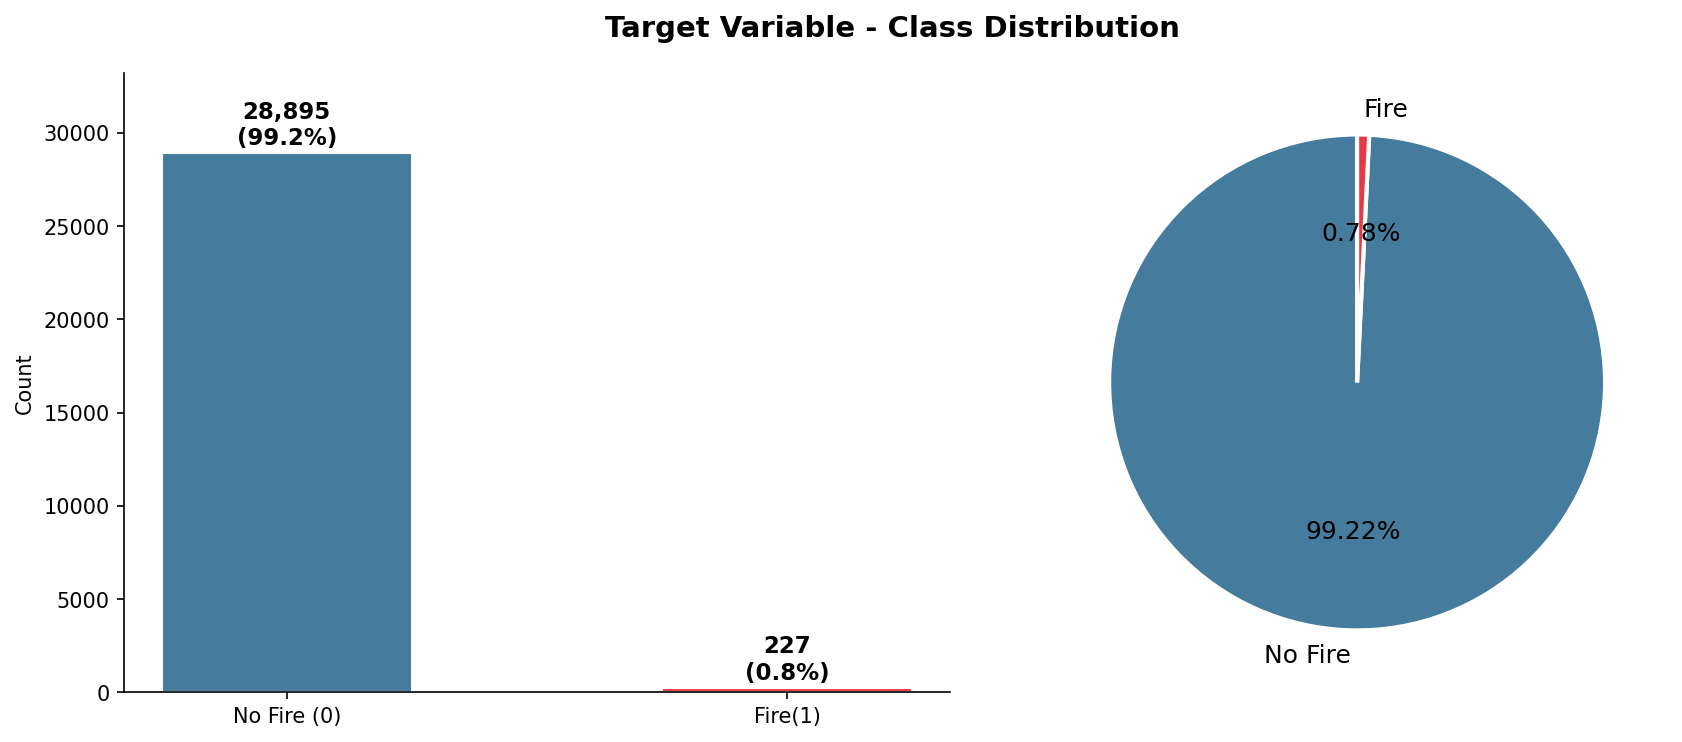

In [17]:
# fig 1 - class imbalance
counts = df['fire_occurred'].value_counts().sort_index()
labels = ['No Fire (0)', "Fire(1)"]
colors = [NO_FIRE_CLR, FIRE_COLOR]

fig, (ax1, ax2) = plt.subplots(1,2, figsize =(12,5))
fig.suptitle("Target Variable - Class Distribution", fontsize=14, fontweight="bold")

bars = ax1.bar(labels, counts.values, color=colors, width=0.5, edgecolor="white")
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
             f"{val:,}\n({val / len(df) * 100:.1f}%)",
             ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.set_ylabel("Count")
ax1.set_ylim(0, counts.max() * 1.15)
ax1.spines[["top", "right"]].set_visible(False)


#for piechart
# Pie chart
ax2.pie(counts.values, labels=["No Fire", "Fire"], colors=colors,
        autopct="%1.2f%%", startangle=90,
        textprops={"fontsize": 12},
        wedgeprops={"edgecolor": "white", "linewidth": 2})

plt.tight_layout()
plt.savefig("fig1_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
fire   = df[df["fire_occurred"] == 1]
nofire = df[df["fire_occurred"] == 0]

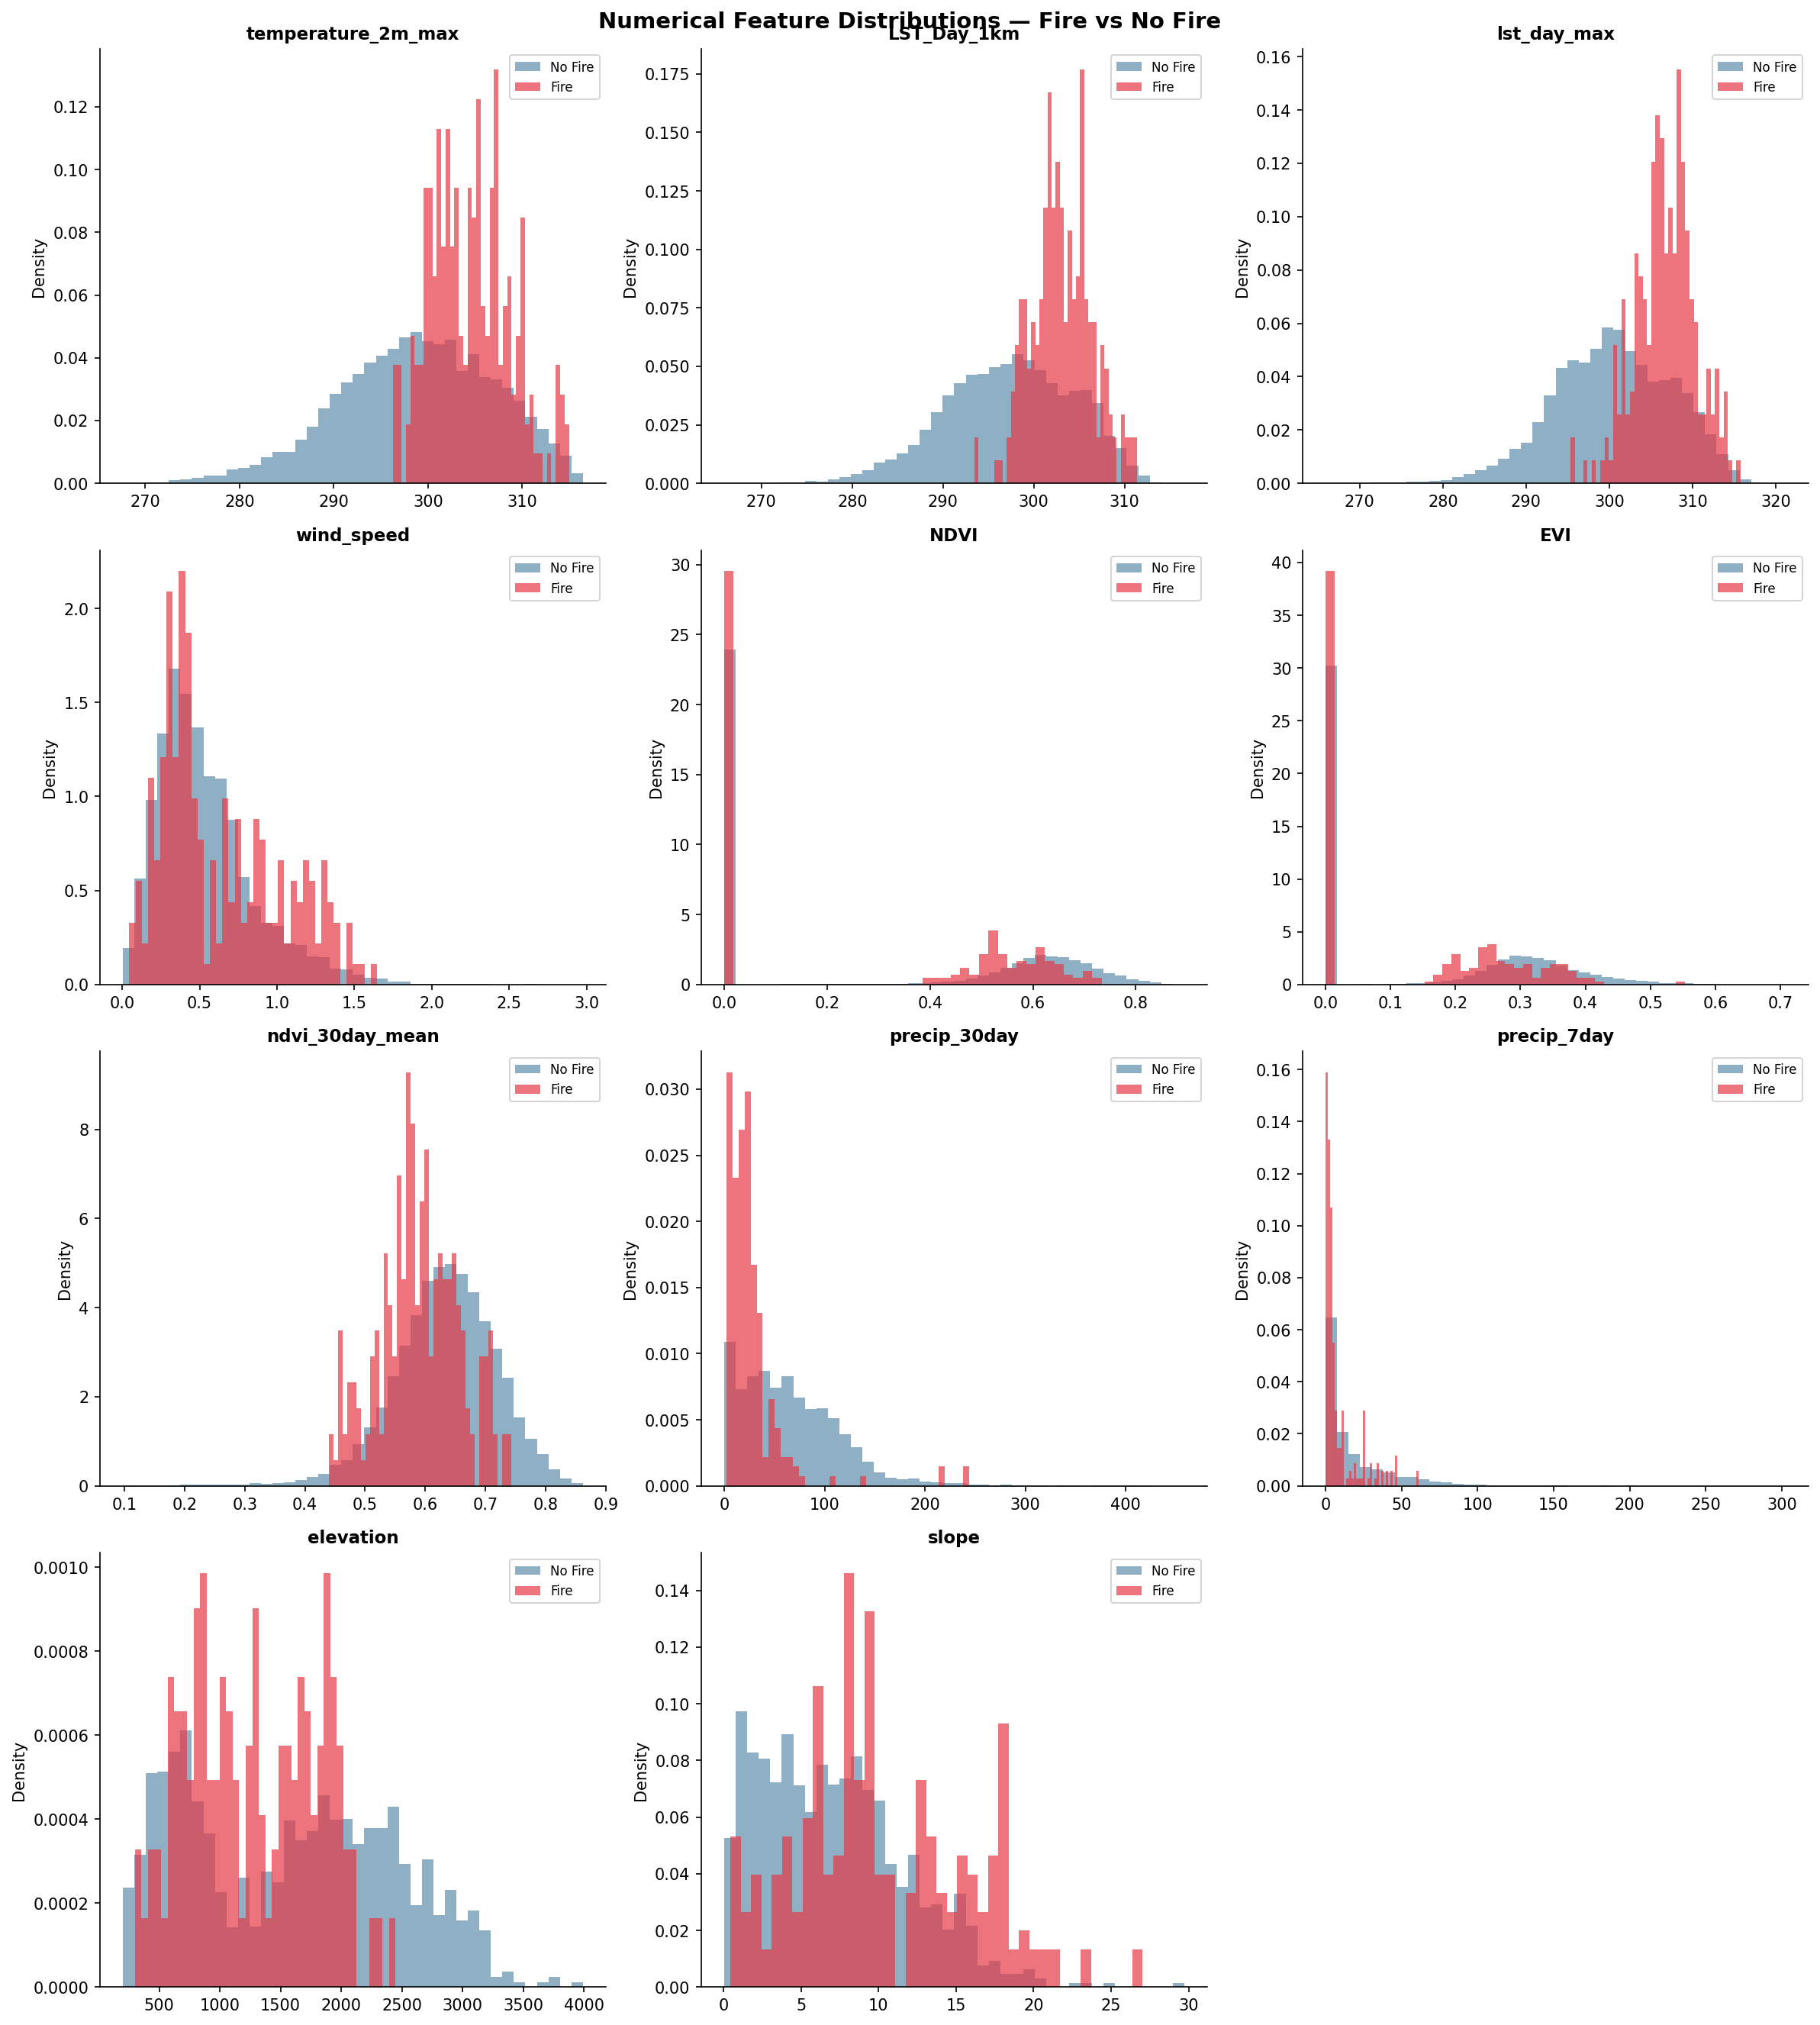

In [20]:
features = [
    "temperature_2m_max", "LST_Day_1km", "lst_day_max", "wind_speed",
    "NDVI", "EVI", "ndvi_30day_mean", "precip_30day", "precip_7day",
    "elevation", "slope",
]

fig, axes = plt.subplots(4, 3, figsize=(16, 18))
fig.suptitle("Numerical Feature Distributions — Fire vs No Fire", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(nofire[feat], bins=40, alpha=0.6, color="#457B9D", label="No Fire", density=True)
    axes[i].hist(fire[feat],   bins=40, alpha=0.7, color="#E63946", label="Fire",    density=True)
    axes[i].set_title(feat, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)
    axes[i].spines[["top", "right"]].set_visible(False)

axes[-1].set_visible(False)   # hide the empty 12th subplot

plt.tight_layout()
plt.savefig("fig2_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

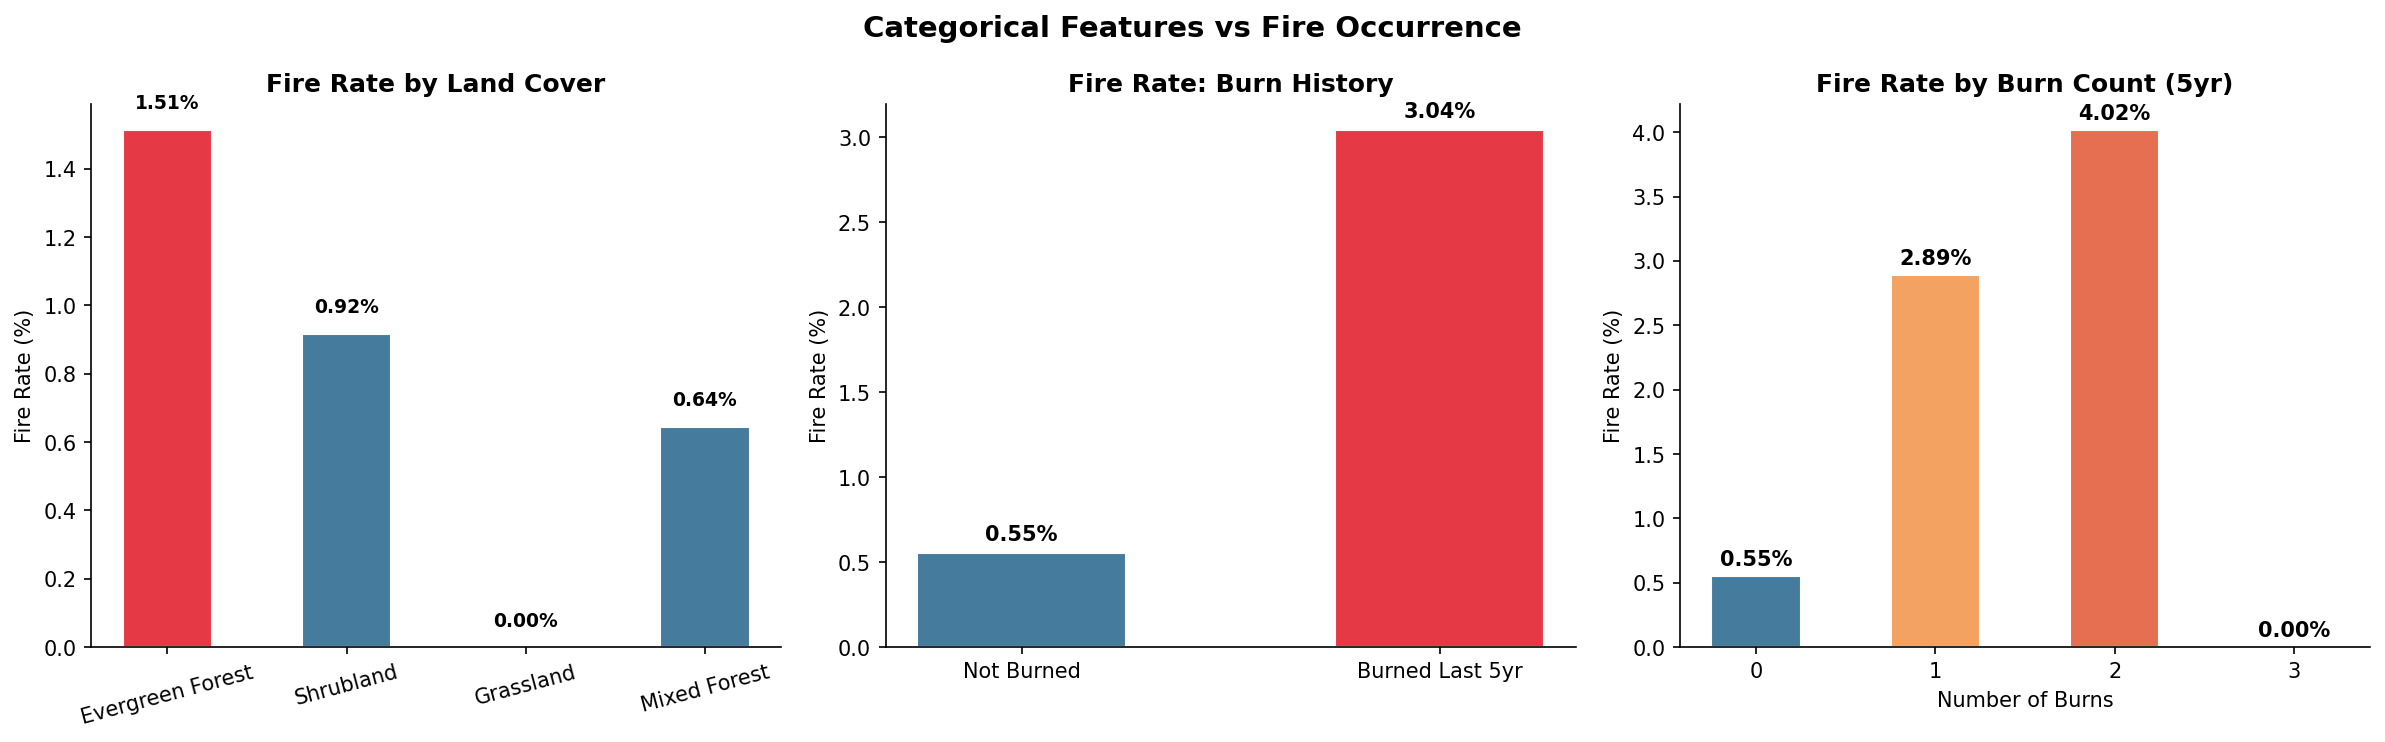

In [21]:
LAND_COVER_MAP = {1: "Evergreen Forest", 2: "Shrubland", 4: "Grassland", 5: "Mixed Forest"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Categorical Features vs Fire Occurrence", fontsize=14, fontweight="bold")

# ── Land cover fire rate ──────────────────────────────────────────────────────
lc = df.groupby("land_cover")["fire_occurred"].mean()
lc.index = lc.index.map(LAND_COVER_MAP)
colors = ["#E63946" if v > 0.01 else "#457B9D" for v in lc.values]
bars = axes[0].bar(lc.index, lc.values * 100, color=colors, width=0.5, edgecolor="white")
for bar, val in zip(bars, lc.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{val*100:.2f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Fire Rate by Land Cover", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Fire Rate (%)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].spines[["top", "right"]].set_visible(False)

# ── Burned in last 5 years ────────────────────────────────────────────────────
bl = df.groupby("burned_last_5yr")["fire_occurred"].mean()
bars2 = axes[1].bar(["Not Burned", "Burned Last 5yr"], bl.values * 100,
                    color=["#457B9D", "#E63946"], width=0.5, edgecolor="white")
for bar, val in zip(bars2, bl.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{val*100:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_title("Fire Rate: Burn History", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Fire Rate (%)")
axes[1].spines[["top", "right"]].set_visible(False)

# ── Burn count over 5 years ───────────────────────────────────────────────────
bc = df.groupby("burn_count_5yr")["fire_occurred"].mean()
gradient_colors = ["#457B9D", "#f4a261", "#e76f51", "#E63946"][:len(bc)]
bars3 = axes[2].bar([str(x) for x in bc.index], bc.values * 100,
                    color=gradient_colors, width=0.5, edgecolor="white")
for bar, val in zip(bars3, bc.values):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{val*100:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[2].set_title("Fire Rate by Burn Count (5yr)", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Number of Burns")
axes[2].set_ylabel("Fire Rate (%)")
axes[2].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig3_categorical.png", dpi=150, bbox_inches="tight")
plt.show()

Top correlations with fire_occurred:
burned_last_5yr          0.081656
burn_count_5yr           0.078901
lst_day_max              0.077501
LST_Day_1km              0.071464
precip_30day             0.069328
LST_Night_1km            0.068009
temperature_2m_max       0.060696
slope                    0.058903
years_since_last_burn    0.055591
ndvi_30day_mean          0.042508
Name: fire_occurred, dtype: float64


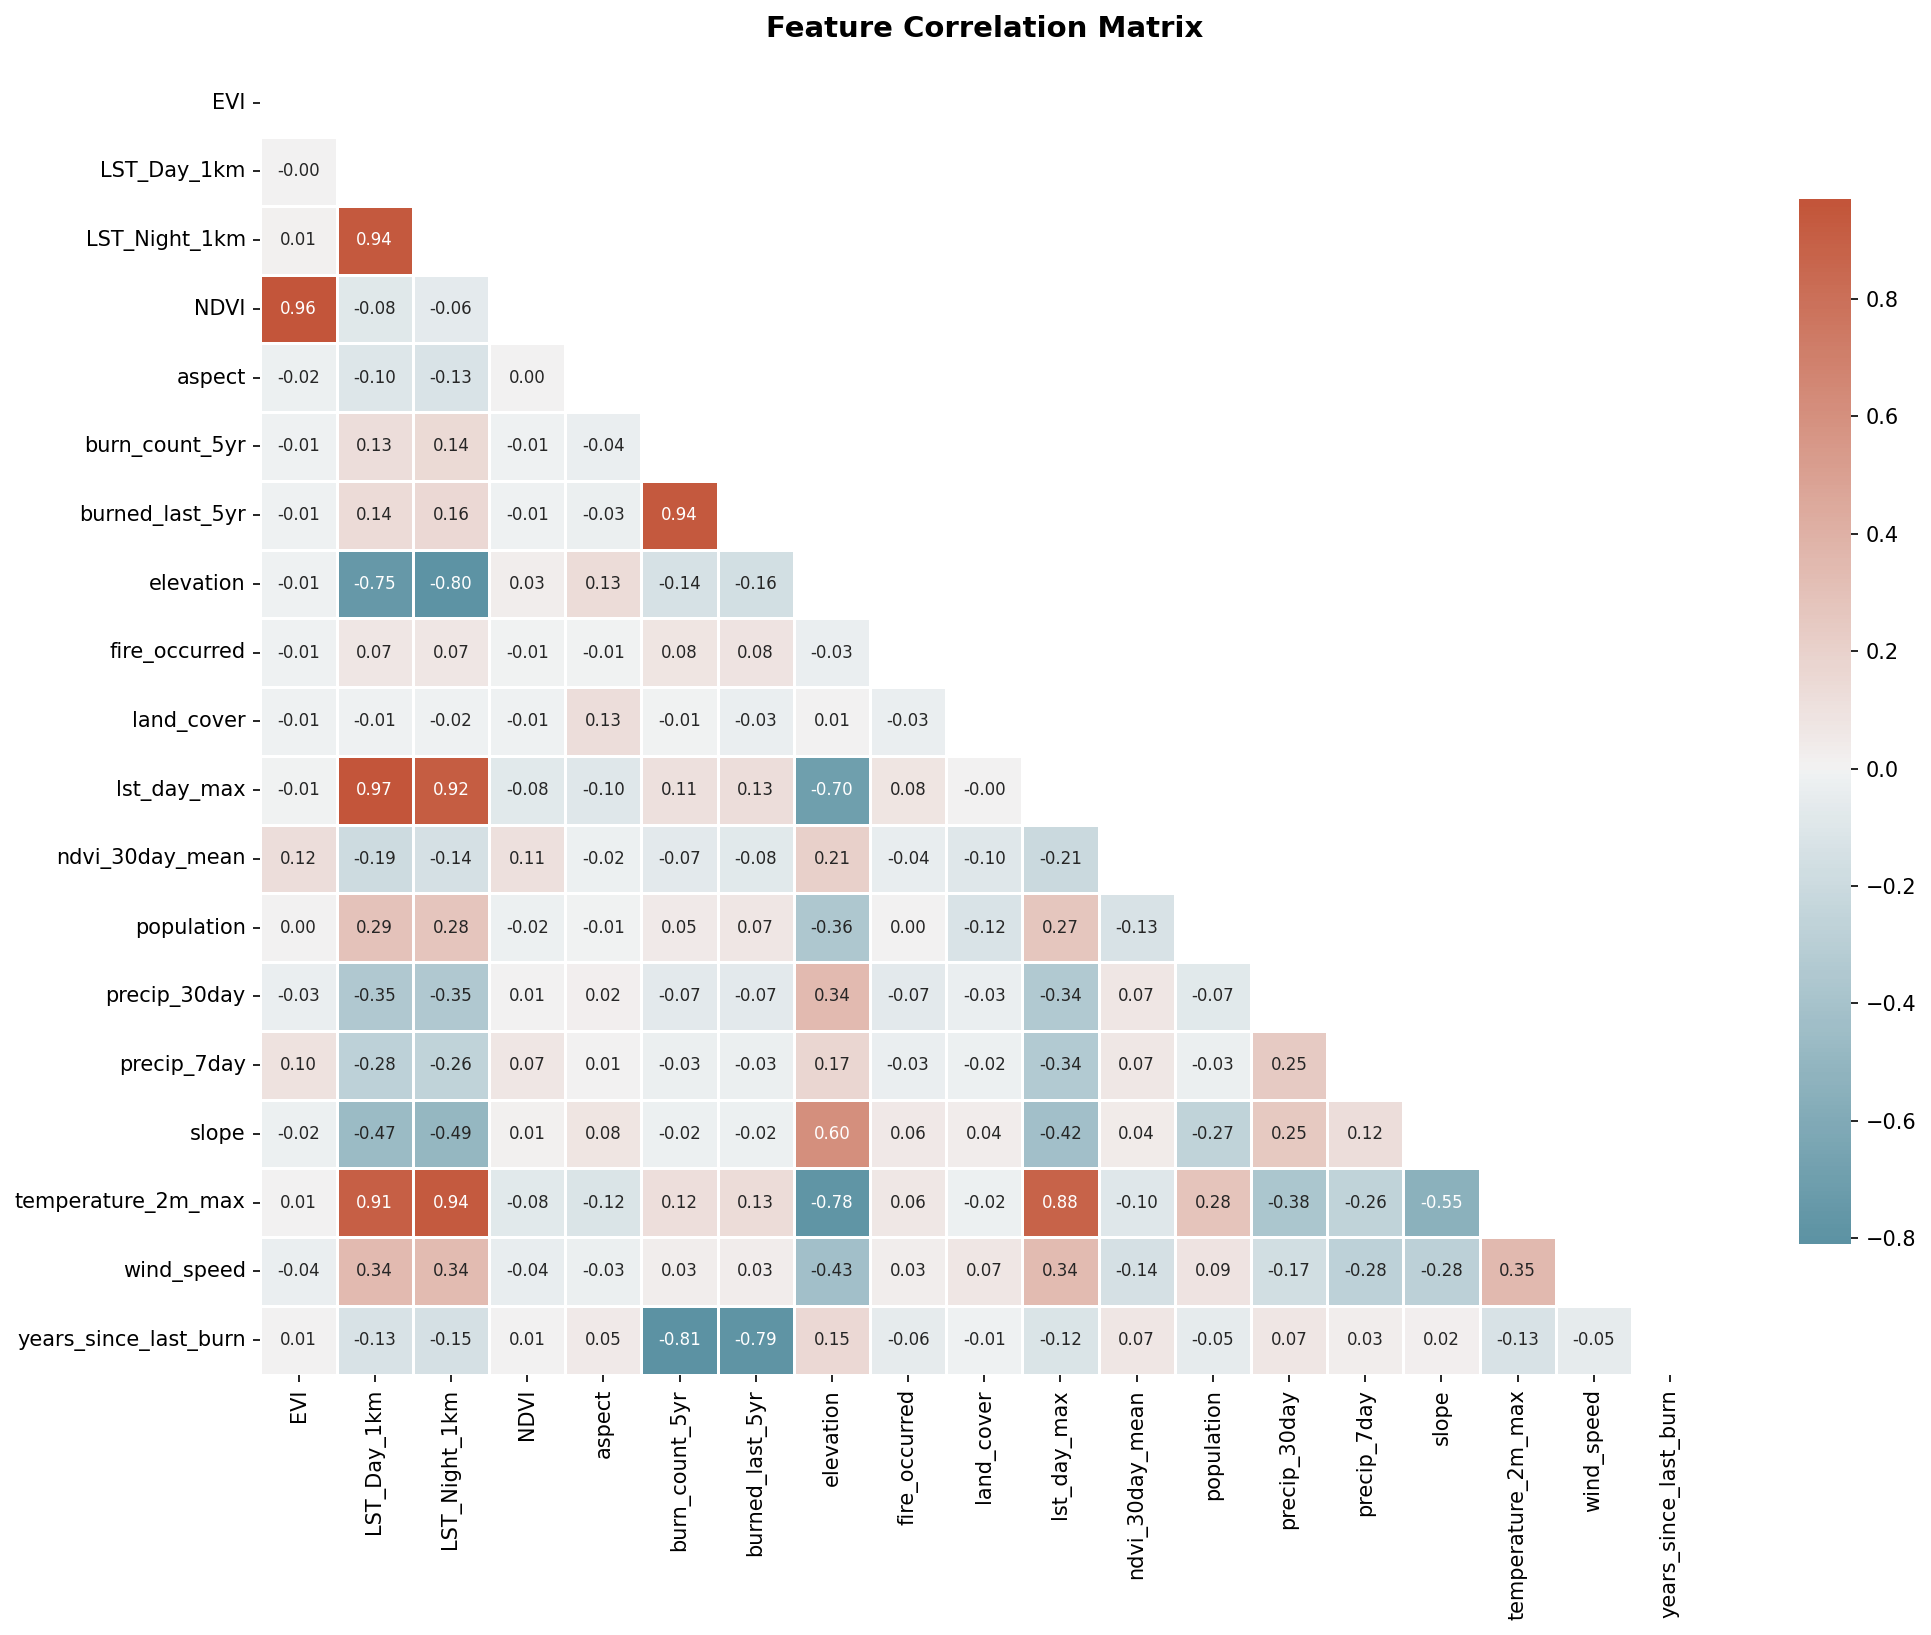

In [22]:
# Drop constant + geo columns before correlating
df = df.drop(columns=["soil_moisture", "longitude", "latitude"])
corr = df.corr()

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
sns.heatmap(corr, mask=mask, ax=ax,
            cmap=sns.diverging_palette(220, 20, as_cmap=True),
            center=0, annot=True, fmt=".2f",
            linewidths=0.5, annot_kws={"size": 8},
            cbar_kws={"shrink": 0.8})

ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=15)

# Print top correlations with target
print("Top correlations with fire_occurred:")
print(corr["fire_occurred"].drop("fire_occurred").abs().sort_values(ascending=False).head(10))

plt.tight_layout()
plt.savefig("fig4_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

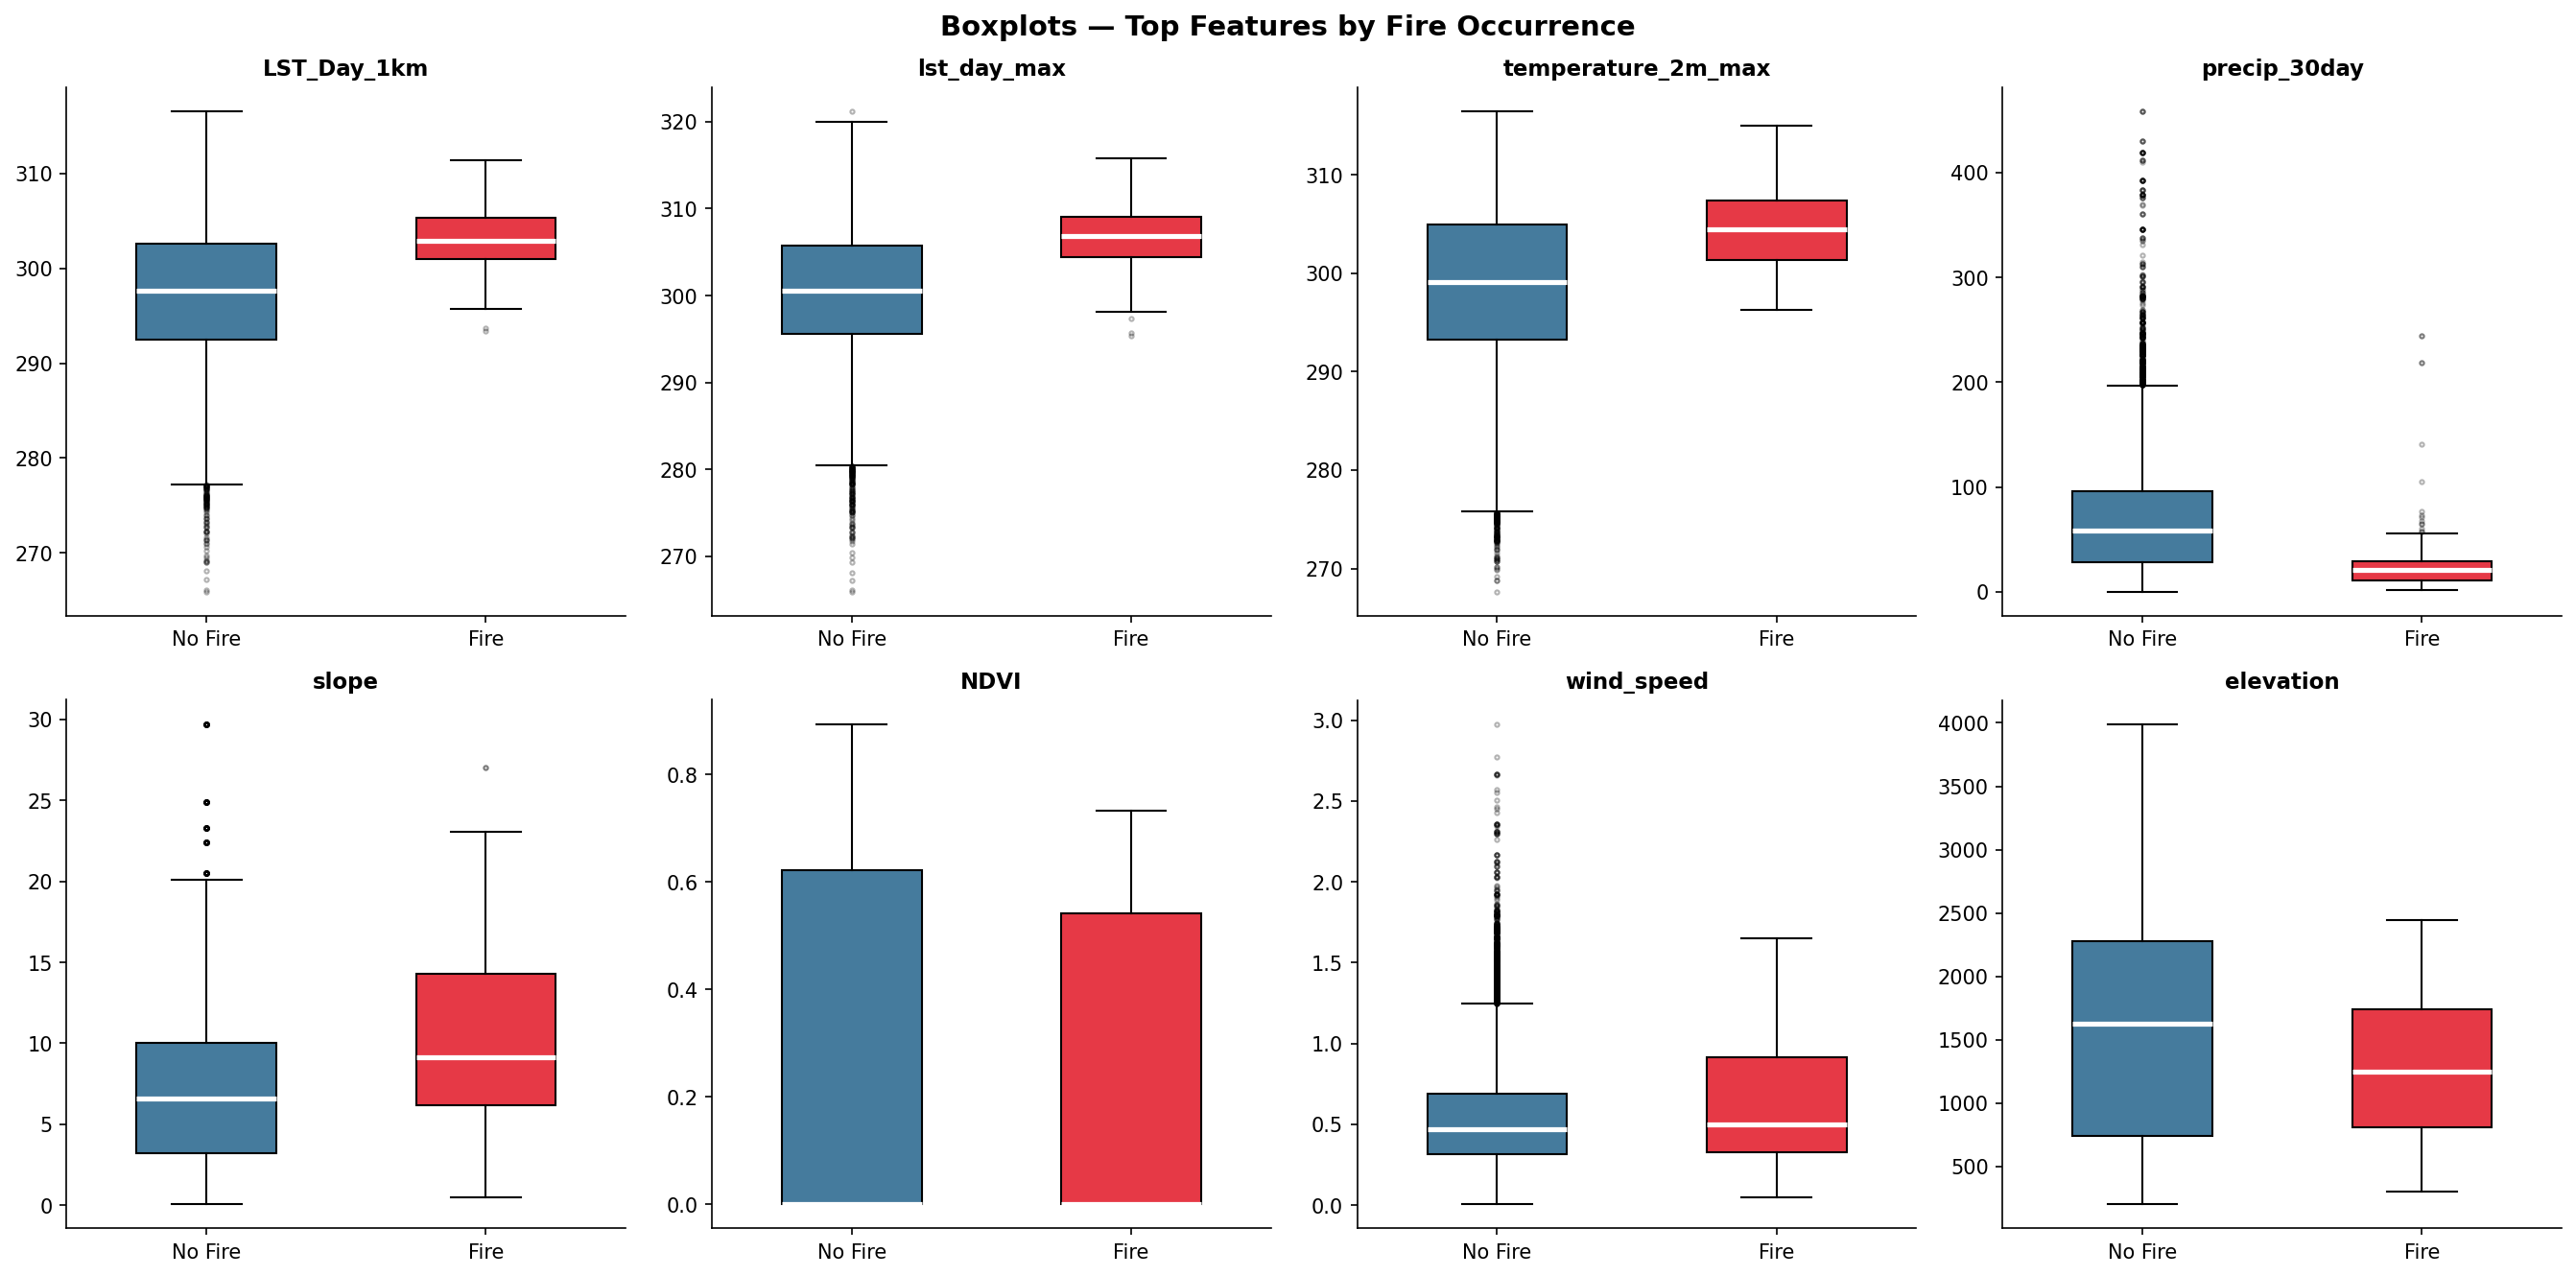

In [23]:
features = [
    "LST_Day_1km", "lst_day_max", "temperature_2m_max", "precip_30day",
    "slope", "NDVI", "wind_speed", "elevation",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Boxplots — Top Features by Fire Occurrence", fontsize=14, fontweight="bold")
axes = axes.flatten()

for i, feat in enumerate(features):
    bp = axes[i].boxplot(
        [nofire[feat].dropna(), fire[feat].dropna()],
        patch_artist=True, widths=0.5,
        medianprops={"color": "white", "linewidth": 2.5},
    )
    bp["boxes"][0].set_facecolor("#457B9D")
    bp["boxes"][1].set_facecolor("#E63946")
    for flier in bp["fliers"]:
        flier.set(marker="o", markersize=2, alpha=0.3)
    axes[i].set_xticklabels(["No Fire", "Fire"], fontsize=10)
    axes[i].set_title(feat, fontsize=11, fontweight="bold")
    axes[i].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig5_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

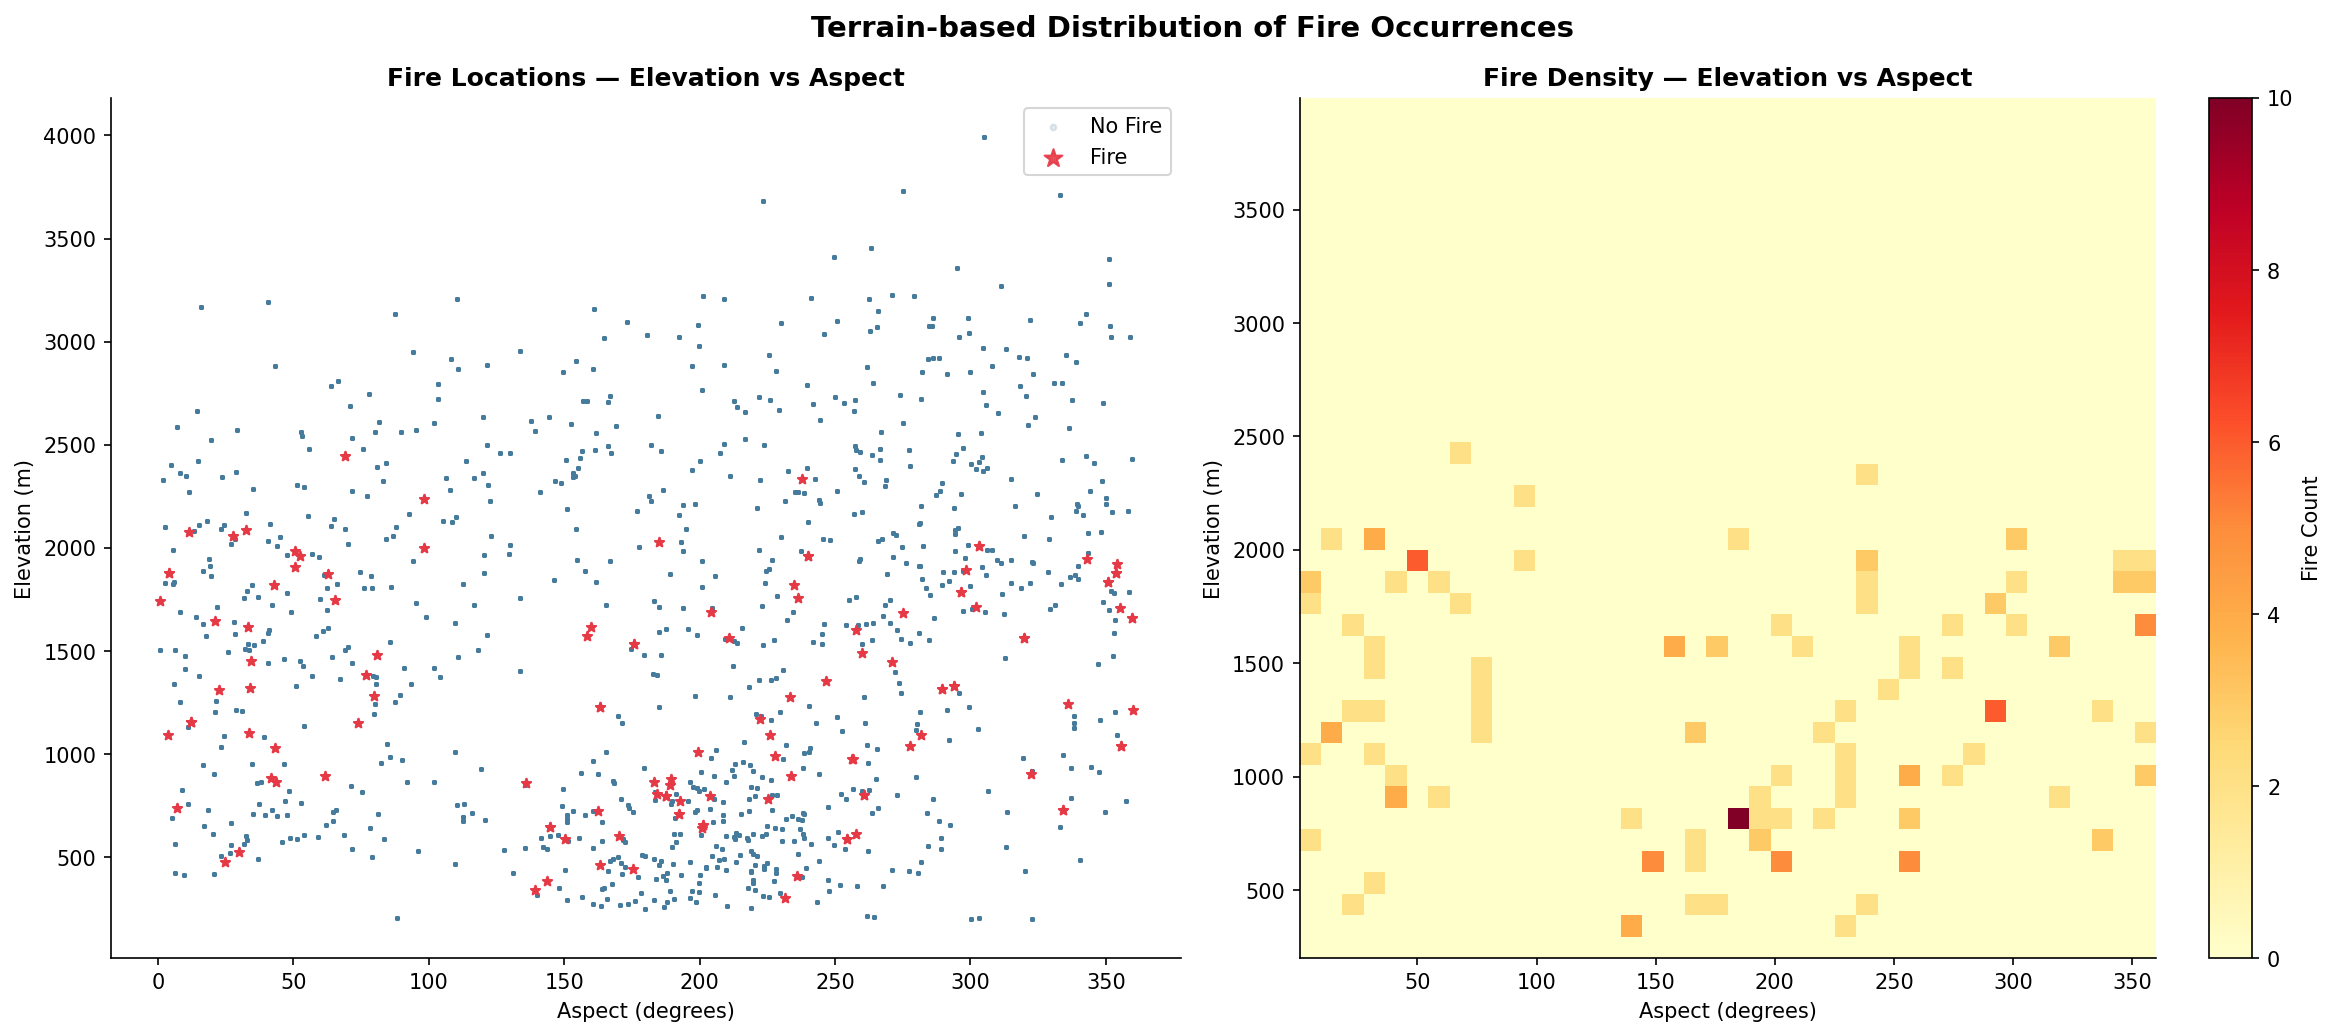

In [26]:
fire   = df[df["fire_occurred"] == 1]
nofire = df[df["fire_occurred"] == 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Terrain-based Distribution of Fire Occurrences", fontsize=14, fontweight="bold")

# Elevation vs Aspect scatter
ax1.scatter(nofire["aspect"], nofire["elevation"], s=2,  alpha=0.15, color="#457B9D", label="No Fire")
ax1.scatter(fire["aspect"],   fire["elevation"],   s=20, alpha=0.9,  color="#E63946", label="Fire", zorder=5, marker="*")
ax1.set_xlabel("Aspect (degrees)")
ax1.set_ylabel("Elevation (m)")
ax1.set_title("Fire Locations — Elevation vs Aspect", fontsize=12, fontweight="bold")
ax1.legend(fontsize=10, markerscale=2)
ax1.spines[["top", "right"]].set_visible(False)

# 2D density heatmap on elevation vs aspect
h = ax2.hist2d(df["aspect"], df["elevation"], bins=40, weights=df["fire_occurred"], cmap="YlOrRd")
plt.colorbar(h[3], ax=ax2, label="Fire Count")
ax2.set_xlabel("Aspect (degrees)")
ax2.set_ylabel("Elevation (m)")
ax2.set_title("Fire Density — Elevation vs Aspect", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("fig6_terrain.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
print(df.columns.tolist())


['EVI', 'LST_Day_1km', 'LST_Night_1km', 'NDVI', 'aspect', 'burn_count_5yr', 'burned_last_5yr', 'elevation', 'fire_occurred', 'land_cover', 'lst_day_max', 'ndvi_30day_mean', 'population', 'precip_30day', 'precip_7day', 'slope', 'temperature_2m_max', 'wind_speed', 'years_since_last_burn']


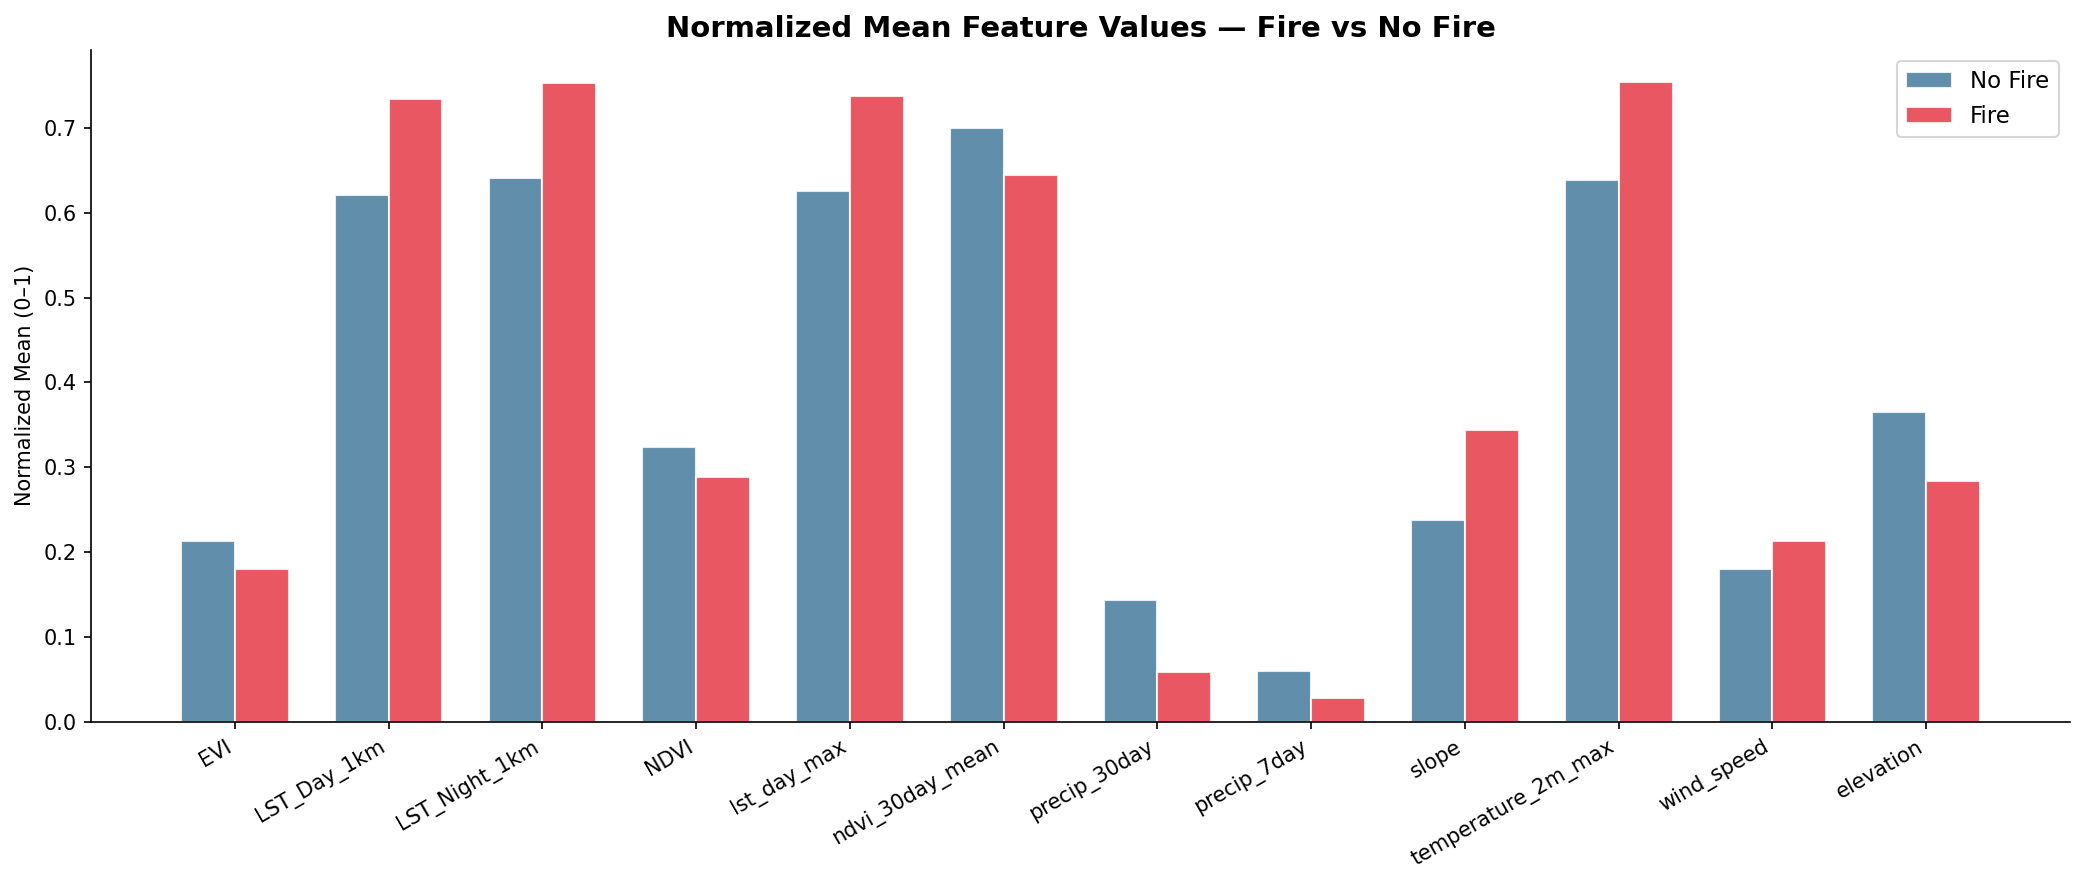

In [27]:
features = [
    "EVI", "LST_Day_1km", "LST_Night_1km", "NDVI", "lst_day_max",
    "ndvi_30day_mean", "precip_30day", "precip_7day",
    "slope", "temperature_2m_max", "wind_speed", "elevation",
]

# Normalize all features to 0-1 for fair comparison
df[features] = MinMaxScaler().fit_transform(df[features])

fire_means   = df[df["fire_occurred"] == 1][features].mean()
nofire_means = df[df["fire_occurred"] == 0][features].mean()

x, w = np.arange(len(features)), 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, nofire_means, w, label="No Fire", color="#457B9D", alpha=0.85, edgecolor="white")
ax.bar(x + w/2, fire_means,   w, label="Fire",    color="#E63946", alpha=0.85, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=30, ha="right", fontsize=10)
ax.set_ylabel("Normalized Mean (0–1)")
ax.set_title("Normalized Mean Feature Values — Fire vs No Fire", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig7_mean_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

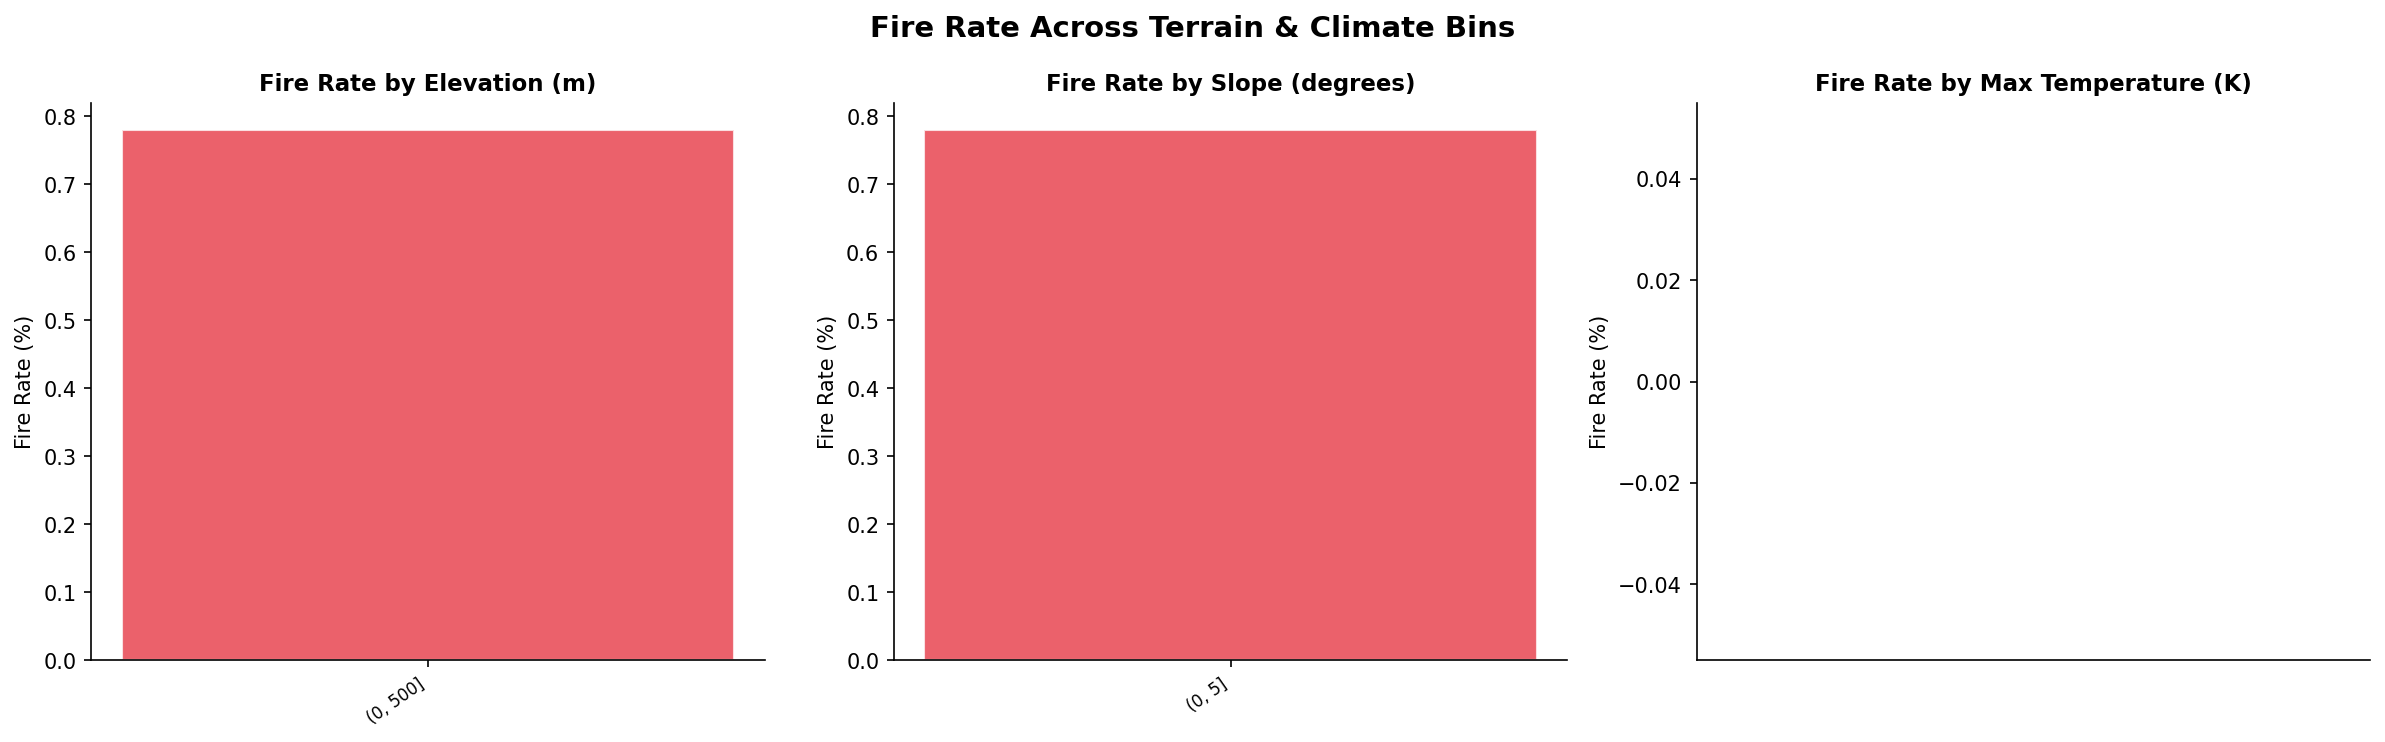

In [29]:
bin_specs = [
    ("elevation",          [0, 500, 1000, 1500, 2000, 2500, 3000, 4000], "Elevation (m)"),
    ("slope",              [0, 5, 10, 15, 20, 25, 30],                   "Slope (degrees)"),
    ("temperature_2m_max", list(range(270, 320, 5)),                      "Max Temperature (K)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Fire Rate Across Terrain & Climate Bins", fontsize=14, fontweight="bold")

for ax, (feat, bins, label) in zip(axes, bin_specs):
    df["_bin"] = pd.cut(df[feat], bins=bins)
    rate = df.groupby("_bin", observed=True)["fire_occurred"].mean() * 100
    ax.bar(range(len(rate)), rate.values, color="#E63946", alpha=0.8, edgecolor="white")
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels([str(b) for b in rate.index], rotation=35, ha="right", fontsize=8)
    ax.set_title(f"Fire Rate by {label}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Fire Rate (%)")
    ax.spines[["top", "right"]].set_visible(False)

df.drop(columns=["_bin"], inplace=True)

plt.tight_layout()
plt.savefig("fig8_terrain_bins.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
# ── Drop useless column ───────────────────────────────────────────────────────
df.drop(columns=["soil_moisture"], inplace=True, errors="ignore")

# ── 1. Heat vs Vegetation Dryness ─────────────────────────────────────────────
# High temp + low NDVI = very dry = high fire risk
df["temp_ndvi_ratio"]    = df["temperature_2m_max"] / (df["NDVI"] + 0.01)
df["temp_evi_ratio"]     = df["temperature_2m_max"] / (df["EVI"]  + 0.01)

# ── 2. LST Day-Night Difference ───────────────────────────────────────────────
# Large gap = dry surface, low moisture retention
df["lst_day_night_diff"] = df["LST_Day_1km"] - df["LST_Night_1km"]

# ── 3. Fire History Risk Score ────────────────────────────────────────────────
# Combines all burn history signals into one score
df["fire_history_score"] = (
    df["burn_count_5yr"] +
    df["burned_last_5yr"] +
    (1 / (df["years_since_last_burn"] + 1))   # recent burns = higher risk
)

# ── 4. Precipitation Dryness ──────────────────────────────────────────────────
# Low recent rain relative to 30-day average = drying out
df["precip_ratio"]       = df["precip_7day"] / (df["precip_30day"] + 0.01)

# ── 5. Terrain Fire Spread Risk ───────────────────────────────────────────────
# Steep + high elevation = fire spreads faster
df["terrain_risk"]       = df["slope"] * np.log1p(df["elevation"])

# ── 6. Vegetation Heat Stress ─────────────────────────────────────────────────
# NDVI dropping below 30-day mean = vegetation drying up
df["ndvi_stress"]        = df["ndvi_30day_mean"] - df["NDVI"]

# ── 7. Extreme Heat Flag ──────────────────────────────────────────────────────
# Binary flag: daytime LST above 305K is a known fire risk threshold
df["extreme_heat"]       = (df["LST_Day_1km"] > 305).astype(int)

# ── Check ─────────────────────────────────────────────────────────────────────
new_features = [
    "temp_ndvi_ratio", "temp_evi_ratio", "lst_day_night_diff",
    "fire_history_score", "precip_ratio", "terrain_risk",
    "ndvi_stress", "extreme_heat"
]

print("New features added:", len(new_features))
print(f"Dataset shape: {df.shape}")
print()
print(df[new_features].describe().round(3))

# Save for next steps
df.to_csv("uttarakhand_fire_engineered.csv", index=False)
print("\nSaved → uttarakhand_fire_engineered.csv")

New features added: 8
Dataset shape: (29122, 27)

       temp_ndvi_ratio  temp_evi_ratio  lst_day_night_diff  \
count        29122.000       29122.000           29122.000   
mean            35.146          35.362              -0.020   
std             34.122          33.907               0.051   
min              0.000           0.000              -0.503   
25%              0.908           1.392              -0.053   
50%             38.900          38.900              -0.022   
75%             66.986          66.986               0.010   
max            100.000         100.000               0.525   

       fire_history_score  precip_ratio  terrain_risk  ndvi_stress  \
count           29122.000     29122.000     29122.000    29122.000   
mean                0.378         0.544         0.087        0.376   
std                 0.680         0.968         0.085        0.362   
min                 0.167         0.000         0.000       -0.500   
25%                 0.167         0.075  

In [32]:
df.drop(columns=["soil_moisture"], inplace=True, errors="ignore")

# ── 1. Heat vs Vegetation Dryness ─────────────────────────────────────────────
df["temp_ndvi_ratio"]    = df["temperature_2m_max"] / (df["NDVI"] + 0.01)
df["temp_evi_ratio"]     = df["temperature_2m_max"] / (df["EVI"]  + 0.01)

# ── 2. Max LST vs Night Diff (more spread than day vs night) ──────────────────
df["lst_maxday_night_diff"] = df["lst_day_max"] - df["LST_Night_1km"]

# ── 3. Fire History Risk Score ────────────────────────────────────────────────
df["fire_history_score"] = (
    df["burn_count_5yr"] +
    df["burned_last_5yr"] +
    (1 / (df["years_since_last_burn"] + 1))
)

# ── 4. Precipitation Dryness ──────────────────────────────────────────────────
df["precip_ratio"]       = df["precip_7day"] / (df["precip_30day"] + 0.01)

# ── 5. Terrain Fire Spread Risk ───────────────────────────────────────────────
df["terrain_risk"]       = df["slope"] * np.log1p(df["elevation"])

# ── 6. Vegetation Heat Stress ─────────────────────────────────────────────────
df["ndvi_stress"]        = df["ndvi_30day_mean"] - df["NDVI"]

# ── 7. Extreme Heat Flag (fixed: use 75th percentile as threshold) ────────────
lst_threshold = df["LST_Day_1km"].quantile(0.75)
df["extreme_heat"]       = (df["LST_Day_1km"] > lst_threshold).astype(int)
print(f"Extreme heat threshold (75th percentile): {lst_threshold:.2f} K")

# ── Check ─────────────────────────────────────────────────────────────────────
new_features = [
    "temp_ndvi_ratio", "temp_evi_ratio", "lst_maxday_night_diff",
    "fire_history_score", "precip_ratio", "terrain_risk",
    "ndvi_stress", "extreme_heat"
]

print(f"\nDataset shape: {df.shape}")
print()
print(df[new_features].describe().round(3))

# Verify extreme_heat has variation now
print(f"\nextreme_heat value counts:\n{df['extreme_heat'].value_counts()}")

# Save
df.to_csv("uttarakhand_fire_engineered.csv", index=False)
print("\nSaved → uttarakhand_fire_engineered.csv")


Extreme heat threshold (75th percentile): 0.73 K

Dataset shape: (29122, 28)

       temp_ndvi_ratio  temp_evi_ratio  lst_maxday_night_diff  \
count        29122.000       29122.000              29122.000   
mean            35.146          35.362                 -0.015   
std             34.122          33.907                  0.059   
min              0.000           0.000                 -0.503   
25%              0.908           1.392                 -0.055   
50%             38.900          38.900                 -0.019   
75%             66.986          66.986                  0.020   
max            100.000         100.000                  0.503   

       fire_history_score  precip_ratio  terrain_risk  ndvi_stress  \
count           29122.000     29122.000     29122.000    29122.000   
mean                0.378         0.544         0.087        0.376   
std                 0.680         0.968         0.085        0.362   
min                 0.167         0.000         0.000   

In [35]:
# ── 1. Define features and target ─────────────────────────────────────────────
X = df.drop(columns=["fire_occurred"])
y = df["fire_occurred"]

# ── 2. Cap extreme ratios to 99th percentile (prevent domination) ─────────────
for col in ["temp_ndvi_ratio", "temp_evi_ratio"]:
    cap = X[col].quantile(0.99)
    X[col] = X[col].clip(upper=cap)
    print(f"{col} capped at: {cap:.3f}")

# ── 3. Train / Test Split (before SMOTE — never apply SMOTE on test set) ──────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size : {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print(f"Train fires: {y_train.sum()}  |  Test fires: {y_test.sum()}")

# ── 4. Scale features (RobustScaler — handles outliers better than Standard) ──
scaler  = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit only on train
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

# ── 5. Apply SMOTE only on training set ───────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nBefore SMOTE → Fire: {y_train.sum()}  |  No Fire: {(y_train==0).sum()}")
print(f"After  SMOTE → Fire: {y_train_resampled.sum()}  |  No Fire: {(y_train_resampled==0).sum()}")
print(f"\nResampled train shape: {X_train_resampled.shape}")

# ── 6. Sanity check class balance ─────────────────────────────────────────────
total = len(y_train_resampled)
fire_pct = y_train_resampled.sum() / total * 100
print(f"\nClass balance after SMOTE: {fire_pct:.1f}% Fire  |  {100-fire_pct:.1f}% No Fire")

temp_ndvi_ratio capped at: 94.534
temp_evi_ratio capped at: 94.534

Train size : 23,297  |  Test size: 5,825
Train fires: 182  |  Test fires: 45

Before SMOTE → Fire: 182  |  No Fire: 23115
After  SMOTE → Fire: 23115  |  No Fire: 23115

Resampled train shape: (46230, 27)

Class balance after SMOTE: 50.0% Fire  |  50.0% No Fire



───────────────────────────────────────────────────────
  Logistic Regression
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     No Fire       1.00      0.84      0.91      5780
        Fire       0.04      0.84      0.07        45

    accuracy                           0.84      5825
   macro avg       0.52      0.84      0.49      5825
weighted avg       0.99      0.84      0.90      5825

  ROC-AUC  : 0.9123
  PR-AUC   : 0.1470  ← most important for imbalanced data

───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     No Fire       1.00      1.00      1.00      5780
        Fire       0.45      0.38      0.41        45

    accuracy                           0.99      5825
   macro avg       0.72      0.69      0.70      5825
weighted avg       0.99      0.99      0.99      5825

  RO

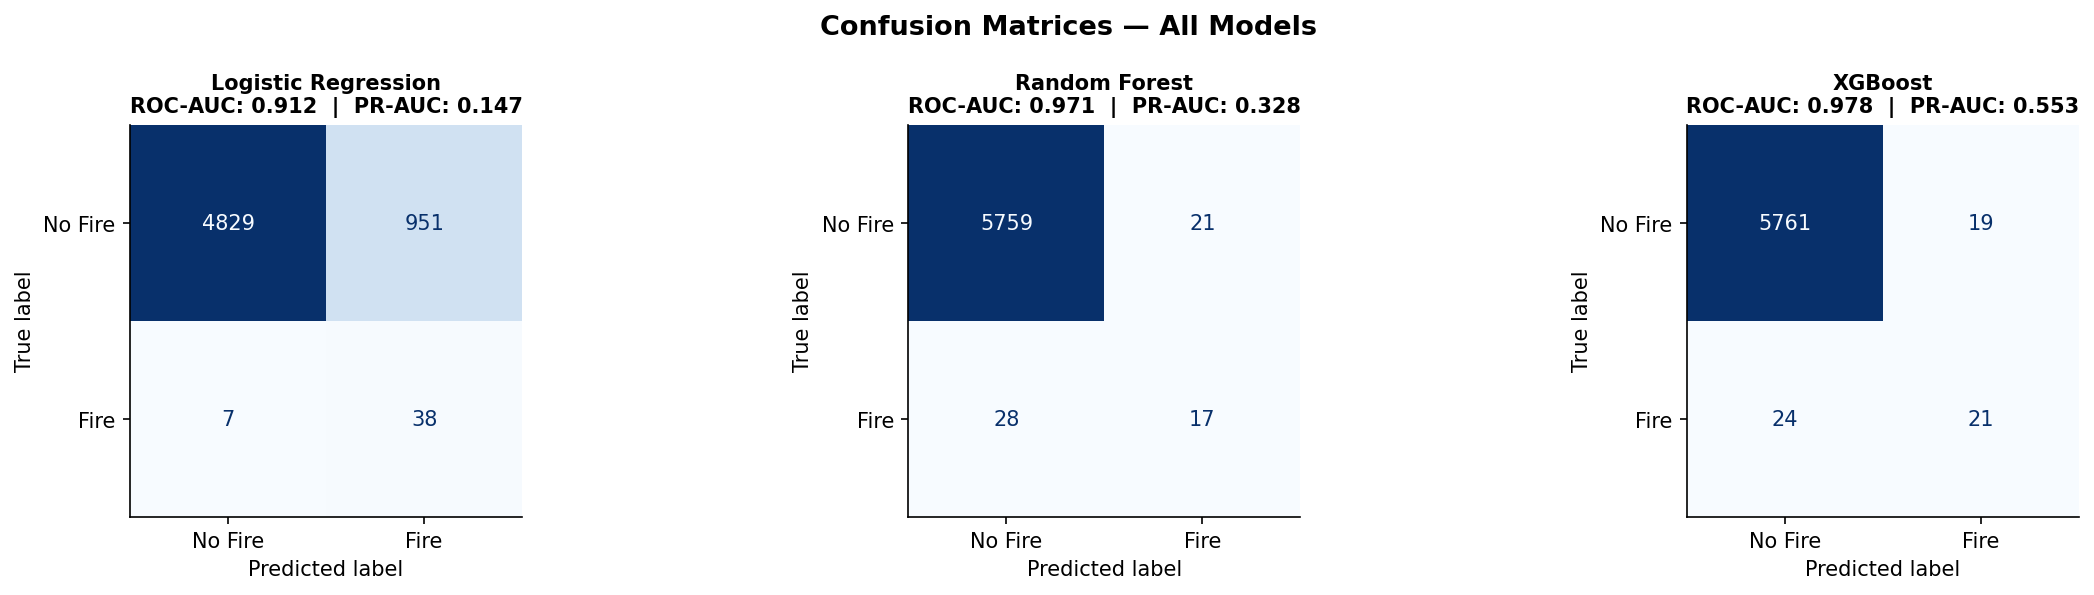



── Final Comparison ──────────────────────────────────────
Model                        ROC-AUC     PR-AUC
───────────────────────────────────────────────
Logistic Regression           0.9123     0.1470
Random Forest                 0.9713     0.3278
XGBoost                       0.9778     0.5526


In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("uttarakhand_fire_engineered.csv")

# ── Reproduce exact same preprocessing as Step 2 ─────────────────────────────
X = df.drop(columns=["fire_occurred"])
y = df["fire_occurred"]

for col in ["temp_ndvi_ratio", "temp_evi_ratio"]:
    X[col] = X[col].clip(upper=X[col].quantile(0.99))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler         = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_res, y_train_res = SMOTE(random_state=42, k_neighbors=5).fit_resample(
    X_train_scaled, y_train
)

# ── Define models ─────────────────────────────────────────────────────────────
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
    "XGBoost"            : xgb.XGBClassifier(n_estimators=200, scale_pos_weight=23115/23115,
                                              eval_metric="aucpr", random_state=42,
                                              use_label_encoder=False),
}

# ── Train + Evaluate all models ───────────────────────────────────────────────
results = {}

for name, model in models.items():
    print(f"\n{'─'*55}")
    print(f"  {name}")
    print(f"{'─'*55}")

    model.fit(X_train_res, y_train_res)

    y_pred      = model.predict(X_test_scaled)
    y_proba     = model.predict_proba(X_test_scaled)[:, 1]

    roc_auc     = roc_auc_score(y_test, y_proba)
    pr_auc      = average_precision_score(y_test, y_proba)

    print(classification_report(y_test, y_pred, target_names=["No Fire", "Fire"]))
    print(f"  ROC-AUC  : {roc_auc:.4f}")
    print(f"  PR-AUC   : {pr_auc:.4f}  ← most important for imbalanced data")

    results[name] = {"model": model, "proba": y_proba, "pred": y_pred,
                     "roc_auc": roc_auc, "pr_auc": pr_auc}

# ── Confusion matrices for all 3 models ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Confusion Matrices — All Models", fontsize=13, fontweight="bold")

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["pred"])
    ConfusionMatrixDisplay(cm, display_labels=["No Fire", "Fire"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{name}\nROC-AUC: {res['roc_auc']:.3f}  |  PR-AUC: {res['pr_auc']:.3f}",
                 fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("fig_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n\n── Final Comparison ──────────────────────────────────────")
print(f"{'Model':<25} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("─" * 47)
for name, res in results.items():
    print(f"{name:<25} {res['roc_auc']:>10.4f} {res['pr_auc']:>10.4f}")

Best threshold (max F1): 0.71

 Threshold  Precision     Recall         F1   Fires Caught
──────────────────────────────────────────────────────────
      0.10      0.299      0.644      0.408         29/45
      0.20      0.384      0.622      0.475         28/45
      0.30      0.426      0.578      0.491         26/45
      0.71      0.690      0.444      0.541         20/45
      0.50      0.525      0.467      0.494         21/45
      0.60      0.600      0.467      0.525         21/45
      0.70      0.667      0.444      0.533         20/45


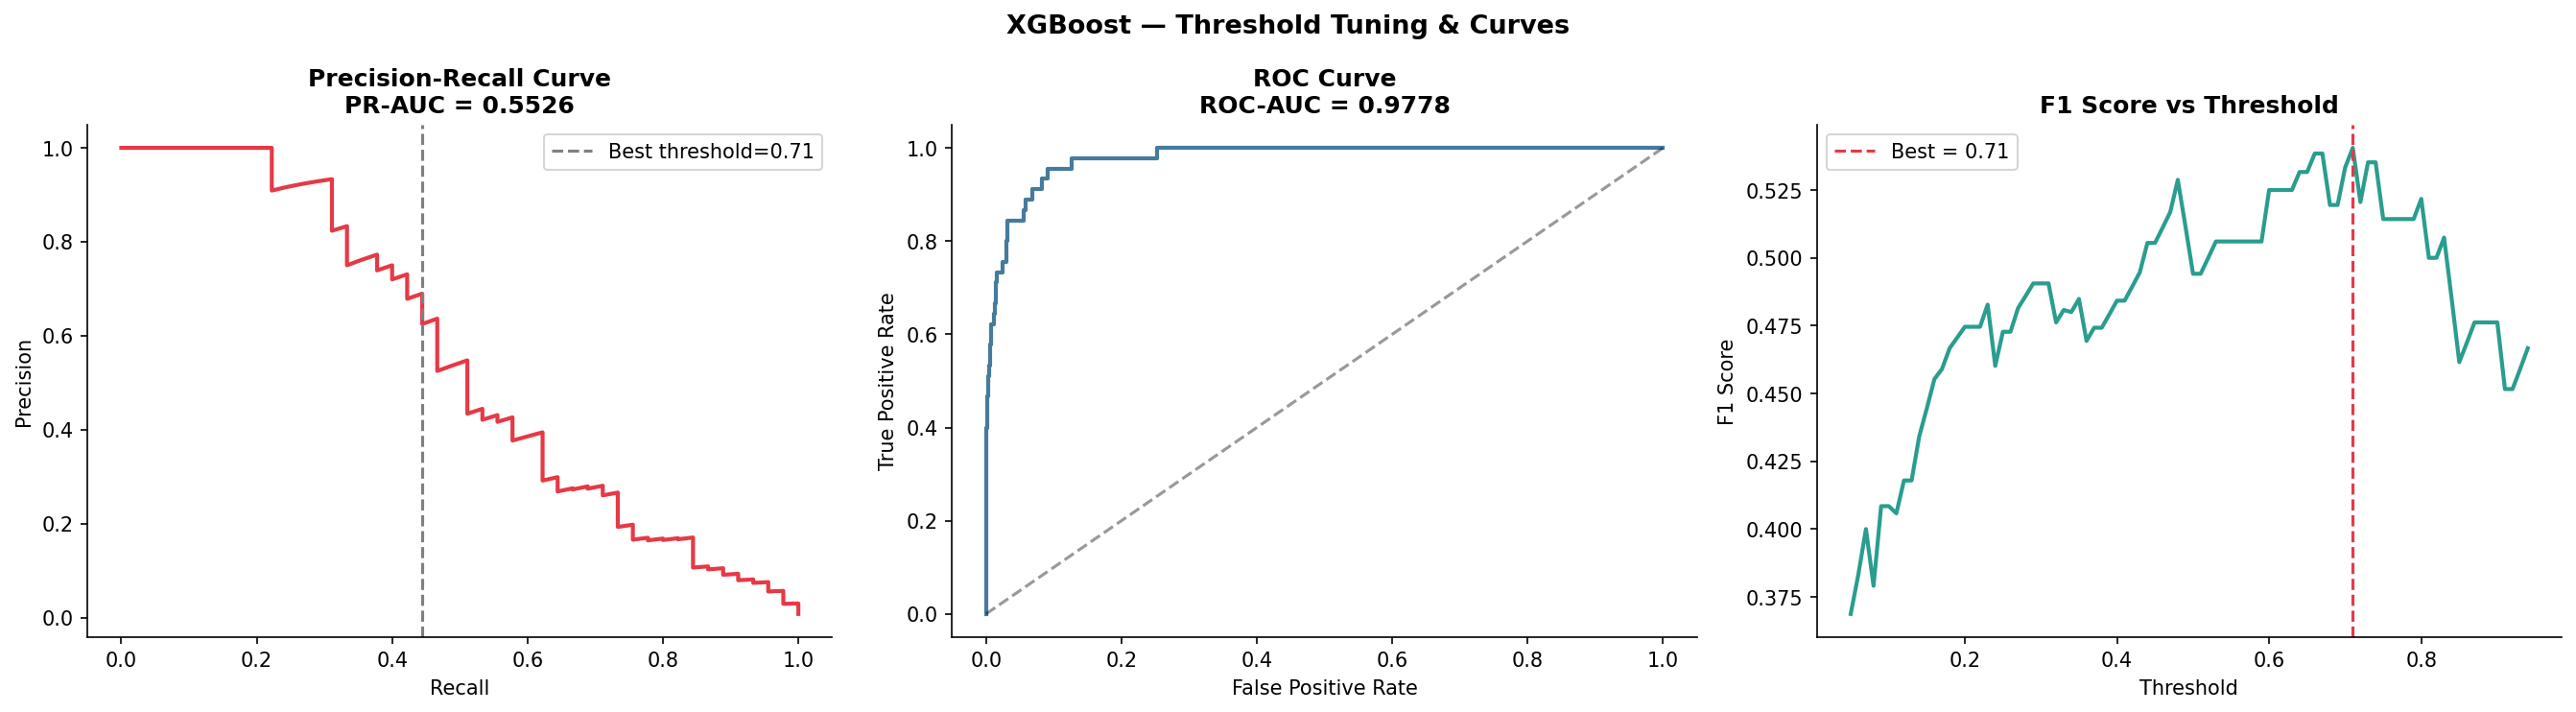

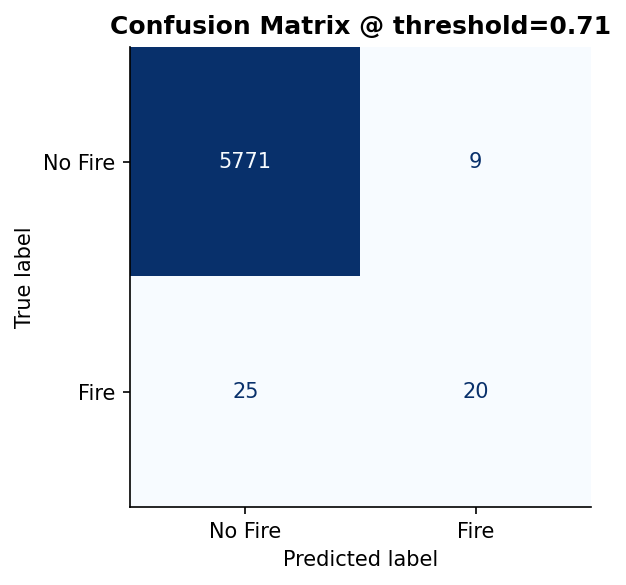

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (precision_recall_curve, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, roc_auc_score, average_precision_score)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("uttarakhand_fire_engineered.csv")

# ── Reproduce preprocessing ───────────────────────────────────────────────────
X = df.drop(columns=["fire_occurred"])
y = df["fire_occurred"]

for col in ["temp_ndvi_ratio", "temp_evi_ratio"]:
    X[col] = X[col].clip(upper=X[col].quantile(0.99))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler         = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_res, y_train_res = SMOTE(random_state=42, k_neighbors=5).fit_resample(
    X_train_scaled, y_train
)

# ── Train XGBoost ─────────────────────────────────────────────────────────────
model = xgb.XGBClassifier(n_estimators=200, eval_metric="aucpr",
                           random_state=42, use_label_encoder=False)
model.fit(X_train_res, y_train_res)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# ── 1. Find best threshold using F1 score ─────────────────────────────────────
thresholds  = np.arange(0.05, 0.95, 0.01)
f1_scores   = [f1_score(y_test, (y_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Best threshold (max F1): {best_thresh:.2f}")

# ── 2. Show metrics at different thresholds ───────────────────────────────────
print(f"\n{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Fires Caught':>14}")
print("─" * 58)
for t in [0.1, 0.2, 0.3, best_thresh, 0.5, 0.6, 0.7]:
    y_pred   = (y_proba >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score
    p  = precision_score(y_test, y_pred, zero_division=0)
    r  = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    caught = y_pred[y_test == 1].sum()
    print(f"{t:>10.2f} {p:>10.3f} {r:>10.3f} {f1:>10.3f} {caught:>10}/{int(y_test.sum())}")

# ── 3. Precision-Recall curve ─────────────────────────────────────────────────
precision, recall, pr_thresh = precision_recall_curve(y_test, y_proba)
fpr, tpr, roc_thresh         = roc_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("XGBoost — Threshold Tuning & Curves", fontsize=13, fontweight="bold")

# PR Curve
axes[0].plot(recall, precision, color="#E63946", linewidth=2)
axes[0].axvline(x=recall[np.argmin(np.abs(pr_thresh - best_thresh))],
                color="gray", linestyle="--", label=f"Best threshold={best_thresh:.2f}")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall Curve\nPR-AUC = {average_precision_score(y_test, y_proba):.4f}",
                  fontweight="bold")
axes[0].legend(); axes[0].spines[["top", "right"]].set_visible(False)

# ROC Curve
axes[1].plot(fpr, tpr, color="#457B9D", linewidth=2)
axes[1].plot([0,1],[0,1], "k--", alpha=0.4)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title(f"ROC Curve\nROC-AUC = {roc_auc_score(y_test, y_proba):.4f}", fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)

# F1 vs Threshold
axes[2].plot(thresholds, f1_scores, color="#2a9d8f", linewidth=2)
axes[2].axvline(x=best_thresh, color="#E63946", linestyle="--", label=f"Best = {best_thresh:.2f}")
axes[2].set_xlabel("Threshold"); axes[2].set_ylabel("F1 Score")
axes[2].set_title("F1 Score vs Threshold", fontweight="bold")
axes[2].legend(); axes[2].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig_threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Final confusion matrix at best threshold ───────────────────────────────
y_pred_best = (y_proba >= best_thresh).astype(int)
fig2, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_best),
                       display_labels=["No Fire", "Fire"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix @ threshold={best_thresh:.2f}", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_best_threshold_cm.png", dpi=150, bbox_inches="tight")
plt.show()